# CS 216 Final Project
## Betting Market Inefficiencies in College Basketball Exact Score Markets
**Authors:** Annie Carey (acc109), Peter FitzSimons (pjf18), Gabe Roman (gar30), Henry Irwin (hmi3), Zachary Levy (znl8)

---

### Notebook Structure
| Section | Description |
|---------|-------------|
| 0 | Imports & Setup |
| 1 | Data Loading / Simulation |
| 2 | Feature Engineering (Implied Scores + Errors) |
| 3 | Band-Based Betting Strategy |
| 4 | Statistical Inference + Bootstrapping |
| 5 | Machine Learning Model (Random Forest) |
| 6 | Visualizations (Figs 1–4) |
| 7 | Summary Output |

> **Note:** Section 1 uses a simulated dataset whose statistical properties mirror our real merged dataset (~24,000 NCAA D1 games, 2016–2024). All figures and statistics in the final report are reproduced from the real data; this notebook reproduces the pipeline end-to-end. The real merged dataset and raw sources live in `/data_processed/` and `/data_raw/` respectively in the shared GitHub repo: https://github.com/annieccarey/CS216FinalProject.git

---

## Section 0 — Imports & Setup

In [1]:
# standard library
import warnings
warnings.filterwarnings("ignore")

# data manipulation
import numpy as np
import pandas as pd

# statistics
from scipy import stats

# machine learning
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# render plots inline
%matplotlib inline

# consistent visual style across all figures
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.dpi":       130,
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "font.size":        10
})

# seed everything so results are reproducible
SEED = 216
np.random.seed(SEED)

print("all imports successful.")

all imports successful.


## Section 1 — Data Loading / Simulation

In the final pipeline this section is replaced by:
- `get_odds_data()` — hits The Odds API for historical spreads & totals
- `get_game_results()` — scrapes Sports Reference box scores
- `merge_datasets()` — joins on (canonical_home_team, canonical_away_team, date ±1 day)

For reproducibility we simulate **2,000 games** matching the statistical profile of our real merged dataset (N ≈ 24,000):
- Game totals ~ N(142, 12)
- Spreads ~ Exponential(5), randomly signed
- Score noise ~ N(0, 8.5) per team — consistent with published D1 variance

In [2]:
def simulate_game_data(n_games: int = 2000) -> pd.DataFrame:
    """
    simulate a dataset that mirrors our real merged pipeline output.
    the real version reads from /data_processed/merged_games.csv instead.

    parameters
    ----------
    n_games : int

    returns
    -------
    pd.DataFrame with columns matching the real merged dataset schema
    """

    # --- betting line data ---

    # game totals centered around the D1 average of ~142 pts
    totals = np.random.normal(loc=142, scale=12, size=n_games)

    # spreads are right-skewed — most games are close, a few are lopsided
    spreads = np.random.exponential(scale=5, size=n_games)
    spread_sign = np.random.choice([-1, 1], size=n_games)
    spreads = spreads * spread_sign

    # implied scores from the lines
    # if total = T and spread = S (positive → home favored):
    #   implied_home = (T + S) / 2
    #   implied_away = (T - S) / 2
    implied_home = (totals + spreads) / 2
    implied_away = (totals - spreads) / 2

    # actual scores: implied + independent noise per team
    actual_home = np.round(implied_home + np.random.normal(0, 8.5, n_games)).astype(int)
    actual_away = np.round(implied_away + np.random.normal(0, 8.5, n_games)).astype(int)

    # clip to a realistic range so we don't get negative or absurd scores
    actual_home = np.clip(actual_home, 40, 130)
    actual_away = np.clip(actual_away, 40, 130)

    # --- team-level efficiency features ---
    # in the real pipeline these come from sports reference team season averages.
    # offensive efficiency = points per 100 possessions (higher = better offense).
    # defensive efficiency = points allowed per 100 possessions (lower = better defense).
    # pace = possessions per 40 minutes.
    teams = [f"Team_{i}" for i in range(50)]
    base_date   = pd.Timestamp("2016-11-01")
    random_days = np.random.randint(0, 8 * 120, size=n_games)

    df = pd.DataFrame({
        "game_id":       range(n_games),
        "date":          [base_date + pd.Timedelta(days=int(d)) for d in random_days],
        "home_team":     np.random.choice(teams, size=n_games),
        "away_team":     np.random.choice(teams, size=n_games),
        # sportsbooks set lines in 0.5-pt increments
        "total_line":    np.round(totals  * 2) / 2,
        "spread_line":   np.round(spreads * 2) / 2,
        "actual_home":   actual_home,
        "actual_away":   actual_away,
        "actual_total":  actual_home + actual_away,
        # team efficiency features (simulated; real values from sports reference)
        "home_off_eff":  np.random.normal(105, 5, n_games),  # pts per 100 poss
        "home_def_eff":  np.random.normal(105, 5, n_games),  # pts allowed per 100 poss
        "away_off_eff":  np.random.normal(105, 5, n_games),
        "away_def_eff":  np.random.normal(105, 5, n_games),
        "home_pace":     np.random.normal(70, 3, n_games),   # possessions per 40 min
        "away_pace":     np.random.normal(70, 3, n_games),
    })

    return df


# run the simulation
df_raw = simulate_game_data(n_games=2000)

print(f"dataset shape : {df_raw.shape}")
print(f"date range    : {df_raw['date'].min().date()} → {df_raw['date'].max().date()}")
df_raw.head()

dataset shape : (2000, 15)
date range    : 2016-11-01 → 2019-06-18


,game_id,date,home_team,away_team,total_line,spread_line,actual_home,actual_away,actual_total,home_off_eff,home_def_eff,away_off_eff,away_def_eff,home_pace,away_pace
0,0,2018-03-23,Team_34,Team_4,129.5,1.5,69,64,133,101.490782,116.044295,118.024535,102.783363,74.040931,66.128193
1,1,2018-05-28,Team_10,Team_9,150.0,2.0,78,68,146,108.569520,110.146769,106.409081,106.781808,65.348181,69.175232
2,2,2018-06-04,Team_37,Team_9,160.5,-8.5,72,98,170,114.026099,98.570372,111.823478,106.931210,69.314511,71.689818
3,3,2018-09-27,Team_41,Team_27,135.5,-1.0,54,87,141,105.084600,105.124053,102.639947,105.126266,71.624691,76.208665
4,4,2018-01-02,Team_14,Team_18,139.5,-4.5,56,70,126,105.657200,107.124335,110.645182,105.722475,68.952630,64.746409


## Section 2 — Feature Engineering

In [3]:
def compute_implied_and_errors(df: pd.DataFrame) -> pd.DataFrame:
    """
    append implied score columns and signed/absolute prediction error columns.

    'implied' = best-guess final score derived from the pre-game betting line.
    'error'   = actual − implied  (positive → game went over the line).
    """

    # implied scores from the spread and total lines
    df["implied_home"]  = (df["total_line"] + df["spread_line"]) / 2
    df["implied_away"]  = (df["total_line"] - df["spread_line"]) / 2
    df["implied_total"] =  df["total_line"]   # the total line is the implied total

    # signed errors — tell us which direction the line was off
    df["error_home"]  = df["actual_home"]  - df["implied_home"]
    df["error_away"]  = df["actual_away"]  - df["implied_away"]
    df["error_total"] = df["actual_total"] - df["implied_total"]

    # absolute errors — useful for accuracy metrics like MAE
    df["abs_error_home"]  = df["error_home"].abs()
    df["abs_error_away"]  = df["error_away"].abs()
    df["abs_error_total"] = df["error_total"].abs()

    # average pace across both teams — used as an ML feature later
    df["avg_pace"] = (df["home_pace"] + df["away_pace"]) / 2

    # matchup efficiency deltas — rough proxy for expected scoring advantage
    # positive home_off_delta means the home team's offense > away team's defense baseline
    df["home_off_delta"] = df["home_off_eff"] - df["away_def_eff"]
    df["away_off_delta"] = df["away_off_eff"] - df["home_def_eff"]

    return df


df = compute_implied_and_errors(df_raw.copy())

# quick sanity check — MAE should be roughly 6–10 pts per team in D1 basketball
print("mean absolute errors")
print(f"  home score : {df['abs_error_home'].mean():.2f} pts")
print(f"  away score : {df['abs_error_away'].mean():.2f} pts")
print(f"  game total : {df['abs_error_total'].mean():.2f} pts")

df[["implied_home", "implied_away", "error_home", "error_away", "error_total"]].describe().round(2)

mean absolute errors
  home score : 6.78 pts
  away score : 6.89 pts
  game total : 9.71 pts


,implied_home,implied_away,error_home,error_away,error_total
count,2000.00,2000.00,2000.00,2000.00,2000.00
mean,70.88,70.98,0.07,-0.18,-0.10
std,6.78,6.96,8.51,8.63,12.18
min,43.75,47.00,-33.00,-30.25,-38.00
25%,66.50,66.50,-5.50,-6.00,-8.50
50%,71.00,71.00,0.00,0.00,0.00
75%,75.25,75.25,6.00,5.50,8.00
max,96.50,96.75,33.75,30.75,51.00


## Section 3 — Band-Based Betting Strategy

**How it works:** for each game we place \$1 on every exact score combination within `±band_width` of the implied score. That's `(2×band_width + 1)²` bets per game.

- **Win** → actual score lands inside the band → collect `payout × $1`
- **Loss** → actual outside the band → forfeit all bets for that game

For the strategy to show positive EV, the empirical hit rate must exceed `n_bets / payout`.

In [4]:
def compute_band_ev(
    df: pd.DataFrame,
    band_width: int,
    payout_multiplier: float = 100.0,
    use_ml_implied: bool = False
) -> pd.Series:
    """
    simulate the band betting strategy and return per-game P&L.

    parameters
    ----------
    df                : dataframe with error columns (or ml_error columns if use_ml_implied)
    band_width        : half-width of the score band in points
    payout_multiplier : decimal odds for an exact-score win (~100x is realistic)
    use_ml_implied    : if true, use ml model residuals instead of line residuals

    returns
    -------
    pd.Series of per-game P&L, with hit rate and n_bets in attrs
    """

    n_bets = (2 * band_width + 1) ** 2  # square grid of (home, away) combos

    if use_ml_implied and "ml_error_home" in df.columns:
        home_hit = df["ml_error_home"].abs() <= band_width
        away_hit = df["ml_error_away"].abs() <= band_width
    else:
        home_hit = df["error_home"].abs() <= band_width
        away_hit = df["error_away"].abs() <= band_width

    win_mask = home_hit & away_hit

    # net P&L: win case returns payout minus cost of all bets placed that game
    profit = np.where(
        win_mask,
        payout_multiplier - n_bets,
        -n_bets
    )

    result = pd.Series(profit, index=df.index, name=f"pnl_band{band_width}")
    result.attrs["win_mask"]   = win_mask.values
    result.attrs["n_bets"]     = n_bets
    result.attrs["band_width"] = band_width

    return result


PAYOUT      = 100.0
BAND_WIDTHS = [1, 2, 3, 4, 5, 6, 7]

print(f"{'Band':>6}  {'N Bets':>8}  {'Hit Rate':>10}  {'Break-Even':>12}  {'Mean P&L':>10}")
print("-" * 56)

for bw in BAND_WIDTHS:
    pnl       = compute_band_ev(df, band_width=bw, payout_multiplier=PAYOUT)
    hit_rate  = pnl.attrs["win_mask"].mean()
    n_bets    = pnl.attrs["n_bets"]
    breakeven = n_bets / PAYOUT
    mean_pnl  = pnl.mean()
    print(f"  ±{bw:>2}   {n_bets:>6}    {hit_rate:>8.2%}    {breakeven:>8.2%}    ${mean_pnl:>7.2f}")

  Band    N Bets    Hit Rate    Break-Even    Mean P&L
--------------------------------------------------------
  ± 1        9       1.10%       9.00%    $  -7.90
  ± 2       25       3.90%      25.00%    $ -21.10
  ± 3       49       8.10%      49.00%    $ -40.90
  ± 4       81      14.25%      81.00%    $ -66.75
  ± 5      121      20.05%     121.00%    $-100.95
  ± 6      169      27.90%     169.00%    $-141.10
  ± 7      225      36.10%     225.00%    $-188.90


## Section 4 — Statistical Inference + Bootstrapping

Three core tests on the line-implied errors, then a bootstrap to build confidence intervals on expected value for each band width.

| Test | H₀ | Alternative |
|------|----|-------------|
| t-test (total error) | Mean error = 0 | Lines are systematically biased |
| t-test (home error)  | Mean home error = 0 | Home scores are biased |
| Shapiro-Wilk         | Errors are normal | Non-normal distribution |

In [5]:
def run_inference(df: pd.DataFrame) -> dict:
    """
    run the three core hypothesis tests on prediction errors.
    returns a dict of results for printing and the final report.
    """

    results = {}

    # --- test 1: is the game total error systematically biased? ---
    # if sportsbooks are efficient, the average error should be zero
    t1, p1 = stats.ttest_1samp(df["error_total"], popmean=0)
    results["total_error_bias"] = {
        "test":       "one-sample t-test",
        "t_stat":     round(t1, 4),
        "p_value":    round(p1, 4),
        "mean_error": round(df["error_total"].mean(), 4),
        "conclusion": "reject H0 — bias detected" if p1 < 0.05 else "fail to reject H0 — no bias"
    }

    # --- test 2: is the home score prediction biased? ---
    t2, p2 = stats.ttest_1samp(df["error_home"], popmean=0)
    results["home_error_bias"] = {
        "test":       "one-sample t-test",
        "t_stat":     round(t2, 4),
        "p_value":    round(p2, 4),
        "mean_error": round(df["error_home"].mean(), 4),
        "conclusion": "reject H0 — bias detected" if p2 < 0.05 else "fail to reject H0 — no bias"
    }

    # --- test 3: are total errors normally distributed? ---
    # shapiro-wilk is most reliable for n < 5000, so we sample if needed
    sample = df["error_total"].sample(min(1000, len(df)), random_state=42)
    w, pw  = stats.shapiro(sample)
    results["normality_total_error"] = {
        "test":       "shapiro-wilk",
        "W_stat":     round(w, 4),
        "p_value":    round(pw, 4),
        "conclusion": "reject normality" if pw < 0.05 else "consistent with normality"
    }

    return results


inference_results = run_inference(df)

for test_name, res in inference_results.items():
    print(f"\n{'─'*52}")
    print(f"  {test_name.upper().replace('_', ' ')}")
    print(f"{'─'*52}")
    for k, v in res.items():
        print(f"  {k:<15}: {v}")


────────────────────────────────────────────────────
  TOTAL ERROR BIAS
────────────────────────────────────────────────────
  test           : one-sample t-test
  t_stat         : -0.38
  p_value        : 0.704
  mean_error     : -0.1035
  conclusion     : fail to reject H0 — no bias

────────────────────────────────────────────────────
  HOME ERROR BIAS
────────────────────────────────────────────────────
  test           : one-sample t-test
  t_stat         : 0.3887
  p_value        : 0.6976
  mean_error     : 0.074
  conclusion     : fail to reject H0 — no bias

────────────────────────────────────────────────────
  NORMALITY TOTAL ERROR
────────────────────────────────────────────────────
  test           : shapiro-wilk
  W_stat         : 0.9989
  p_value        : 0.7968
  conclusion     : consistent with normality


In [6]:
def bootstrap_band_ev(
    df: pd.DataFrame,
    band_width: int,
    payout_multiplier: float = 100.0,
    n_bootstrap: int = 2000,
    use_ml_implied: bool = False,
    random_state: int = SEED
) -> dict:
    """
    bootstrap 95% confidence intervals on mean per-game P&L for a given band width.

    we resample games with replacement n_bootstrap times and recompute mean P&L
    each time — this gives us a distribution of possible mean P&L values without
    assuming any parametric form for the P&L distribution.

    parameters
    ----------
    df                : dataframe with error columns
    band_width        : half-width of the score band
    payout_multiplier : exact-score payout odds
    n_bootstrap       : number of bootstrap resamples
    use_ml_implied    : use ML residuals instead of line residuals

    returns
    -------
    dict with point estimate, lower CI, upper CI, and hit rate
    """

    rng   = np.random.default_rng(random_state)
    n     = len(df)
    means = np.empty(n_bootstrap)

    for i in range(n_bootstrap):
        sample = df.sample(n=n, replace=True, random_state=int(rng.integers(1e6)))
        pnl    = compute_band_ev(sample, band_width, payout_multiplier, use_ml_implied)
        means[i] = pnl.mean()

    pnl_full = compute_band_ev(df, band_width, payout_multiplier, use_ml_implied)

    return {
        "band_width":  band_width,
        "point_est":   pnl_full.mean(),
        "ci_lower":    np.percentile(means, 2.5),
        "ci_upper":    np.percentile(means, 97.5),
        "hit_rate":    pnl_full.attrs["win_mask"].mean(),
        "breakeven":   pnl_full.attrs["n_bets"] / payout_multiplier,
    }


print("bootstrapping 95% CI on mean per-game P&L (this takes a few seconds)...")

bootstrap_results = {}
for bw in [2, 4, 6]:
    bootstrap_results[bw] = bootstrap_band_ev(df, band_width=bw, n_bootstrap=2000)

print("\nband  point_est    95% CI                 hit_rate  break-even")
print("-" * 68)
for bw, r in bootstrap_results.items():
    print(
        f"  ±{bw}   ${r['point_est']:>7.2f}   "
        f"[${r['ci_lower']:>7.2f}, ${r['ci_upper']:>6.2f}]   "
        f"{r['hit_rate']:>7.2%}    {r['breakeven']:>7.2%}"
    )

print("\nnote: if the upper CI bound is negative, the strategy has no positive-EV support.")

bootstrapping 95% CI on mean per-game P&L (this takes a few seconds)...



band  point_est    95% CI                 hit_rate  break-even
--------------------------------------------------------------------
  ±2   $ -21.10   [$ -21.90, $-20.25]     3.90%     25.00%
  ±4   $ -66.75   [$ -68.15, $-65.20]    14.25%     81.00%
  ±6   $-141.10   [$-143.05, $-139.10]    27.90%    169.00%

note: if the upper CI bound is negative, the strategy has no positive-EV support.


## Section 5 — Machine Learning Model

We train two regression models to predict final home and away scores:

1. **Linear Regression** — baseline using the spread and total line only (should match our analytic formula closely)
2. **Random Forest Regressor** — uses the spread, total, team offensive/defensive efficiency ratings, and pace features

If the random forest achieves meaningfully lower RMSE than the line-implied formula, its residuals become the basis for a tighter band strategy — the key question we test at the end of this section.

In [7]:
# --- feature setup ---

FEATURES = [
    "total_line",      # the over/under line — encodes expected scoring pace
    "spread_line",     # positive = home favored; encodes relative team strength
    "home_off_eff",    # home team offensive efficiency rating
    "home_def_eff",    # home team defensive efficiency rating
    "away_off_eff",    # away team offensive efficiency rating
    "away_def_eff",    # away team defensive efficiency rating
    "home_pace",       # home team pace (possessions per 40 min)
    "away_pace",       # away team pace
    "avg_pace",        # average pace across both teams
    "home_off_delta",  # home off eff minus away def eff — net scoring advantage
    "away_off_delta",  # away off eff minus home def eff
]

X      = df[FEATURES]
y_home = df["actual_home"]
y_away = df["actual_away"]

# 80/20 train-test split, stratified randomly
X_train, X_test, yh_train, yh_test, ya_train, ya_test = train_test_split(
    X, y_home, y_away, test_size=0.2, random_state=SEED
)

print(f"train size: {len(X_train):,}   test size: {len(X_test):,}")
print(f"features used: {FEATURES}")

train size: 1,600   test size: 400
features used: ['total_line', 'spread_line', 'home_off_eff', 'home_def_eff', 'away_off_eff', 'away_def_eff', 'home_pace', 'away_pace', 'avg_pace', 'home_off_delta', 'away_off_delta']


In [8]:
# --- model 1: linear regression (baseline) ---

lr_home = LinearRegression()
lr_away = LinearRegression()

lr_home.fit(X_train, yh_train)
lr_away.fit(X_train, ya_train)

# rmse on hold-out test set
lr_pred_home = lr_home.predict(X_test)
lr_pred_away = lr_away.predict(X_test)

lr_rmse_home = np.sqrt(mean_squared_error(yh_test, lr_pred_home))
lr_rmse_away = np.sqrt(mean_squared_error(ya_test, lr_pred_away))

print(f"linear regression — home RMSE: {lr_rmse_home:.3f} pts  |  away RMSE: {lr_rmse_away:.3f} pts")

linear regression — home RMSE: 8.974 pts  |  away RMSE: 8.460 pts


In [9]:
# --- model 2: random forest ---
# 200 trees, max_depth=6 to avoid overfitting on a 1,600-game training set
# in the real pipeline we'd tune these with a proper grid search

rf_home = RandomForestRegressor(n_estimators=200, max_depth=6, random_state=SEED, n_jobs=-1)
rf_away = RandomForestRegressor(n_estimators=200, max_depth=6, random_state=SEED, n_jobs=-1)

rf_home.fit(X_train, yh_train)
rf_away.fit(X_train, ya_train)

rf_pred_home = rf_home.predict(X_test)
rf_pred_away = rf_away.predict(X_test)

rf_rmse_home = np.sqrt(mean_squared_error(yh_test, rf_pred_home))
rf_rmse_away = np.sqrt(mean_squared_error(ya_test, rf_pred_away))

print(f"random forest   — home RMSE: {rf_rmse_home:.3f} pts  |  away RMSE: {rf_rmse_away:.3f} pts")

# improvement over linear regression
delta_home = lr_rmse_home - rf_rmse_home
delta_away = lr_rmse_away - rf_rmse_away
print(f"\nRF improvement over LR  — home: {delta_home:+.3f} pts  |  away: {delta_away:+.3f} pts")

random forest   — home RMSE: 9.259 pts  |  away RMSE: 8.708 pts

RF improvement over LR  — home: -0.284 pts  |  away: -0.248 pts


In [10]:
# --- 5-fold cross-validation on random forest ---
# this is more reliable than a single train/test split because it averages
# over 5 different held-out subsets

kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

cv_home = cross_val_score(
    RandomForestRegressor(n_estimators=200, max_depth=6, random_state=SEED),
    X, y_home, cv=kf, scoring="neg_root_mean_squared_error"
)
cv_away = cross_val_score(
    RandomForestRegressor(n_estimators=200, max_depth=6, random_state=SEED),
    X, y_away, cv=kf, scoring="neg_root_mean_squared_error"
)

print("5-fold cross-validation RMSE (random forest)")
print(f"  home: {(-cv_home).mean():.3f} ± {(-cv_home).std():.3f} pts")
print(f"  away: {(-cv_away).mean():.3f} ± {(-cv_away).std():.3f} pts")

# also report the naive baseline: using the line-implied score directly
line_rmse_home = np.sqrt(mean_squared_error(df["actual_home"], df["implied_home"]))
line_rmse_away = np.sqrt(mean_squared_error(df["actual_away"], df["implied_away"]))
print(f"\nnaïve line-implied baseline")
print(f"  home RMSE: {line_rmse_home:.3f} pts")
print(f"  away RMSE: {line_rmse_away:.3f} pts")

5-fold cross-validation RMSE (random forest)
  home: 8.724 ± 0.387 pts
  away: 8.922 ± 0.289 pts

naïve line-implied baseline
  home RMSE: 8.513 pts
  away RMSE: 8.629 pts


In [11]:
# --- feature importance ---

importance_df = pd.DataFrame({
    "feature":    FEATURES,
    "importance": rf_home.feature_importances_
}).sort_values("importance", ascending=False).reset_index(drop=True)

print("feature importances (home score model):")
print(importance_df.to_string(index=False))

feature importances (home score model):
       feature  importance
    total_line    0.569515
   spread_line    0.218891
  home_def_eff    0.034359
away_off_delta    0.029761
  home_off_eff    0.023938
  away_def_eff    0.022629
     away_pace    0.021790
     home_pace    0.021639
  away_off_eff    0.021164
      avg_pace    0.021038
home_off_delta    0.015276


In [12]:
# --- attach ML predictions and residuals to the full dataframe ---
# we need these later to compare the ML-based band strategy vs the line-based one

df["ml_pred_home"] = rf_home.predict(X)
df["ml_pred_away"] = rf_away.predict(X)

df["ml_error_home"]  = df["actual_home"] - df["ml_pred_home"]
df["ml_error_away"]  = df["actual_away"] - df["ml_pred_away"]
df["ml_error_total"] = df["ml_error_home"] + df["ml_error_away"]

df["ml_abs_error_home"]  = df["ml_error_home"].abs()
df["ml_abs_error_away"]  = df["ml_error_away"].abs()
df["ml_abs_error_total"] = df["ml_error_total"].abs()

print("ML model MAE on full dataset (for reference — test-set RMSE is the fair metric):")
print(f"  home: {df['ml_abs_error_home'].mean():.3f} pts")
print(f"  away: {df['ml_abs_error_away'].mean():.3f} pts")
print(f"  total: {df['ml_abs_error_total'].mean():.3f} pts")

ML model MAE on full dataset (for reference — test-set RMSE is the fair metric):
  home: 6.131 pts
  away: 6.227 pts
  total: 8.757 pts


In [13]:
# --- compare band strategies: line-implied vs ML-implied ---
print("band strategy comparison: line-implied vs ml-implied residuals")
print(f"{'Band':>6}  {'Line Hit%':>10}  {'ML Hit%':>10}  {'Line EV':>10}  {'ML EV':>10}")
print("-" * 58)

for bw in BAND_WIDTHS:
    pnl_line = compute_band_ev(df, band_width=bw, payout_multiplier=PAYOUT, use_ml_implied=False)
    pnl_ml   = compute_band_ev(df, band_width=bw, payout_multiplier=PAYOUT, use_ml_implied=True)
    print(
        f"  ±{bw:>2}   "
        f"{pnl_line.attrs['win_mask'].mean():>9.2%}  "
        f"{pnl_ml.attrs['win_mask'].mean():>9.2%}  "
        f"${pnl_line.mean():>8.2f}  "
        f"${pnl_ml.mean():>8.2f}"
    )
print("\nif ML hit rates are higher, the model is centering the band more accurately.")

band strategy comparison: line-implied vs ml-implied residuals
  Band   Line Hit%     ML Hit%     Line EV       ML EV
----------------------------------------------------------
  ± 1       1.10%      1.05%  $   -7.90  $   -7.95
  ± 2       3.90%      4.00%  $  -21.10  $  -21.00
  ± 3       8.10%      9.15%  $  -40.90  $  -39.85
  ± 4      14.25%     15.95%  $  -66.75  $  -65.05
  ± 5      20.05%     23.25%  $ -100.95  $  -97.75
  ± 6      27.90%     31.25%  $ -141.10  $ -137.75
  ± 7      36.10%     40.60%  $ -188.90  $ -184.40

if ML hit rates are higher, the model is centering the band more accurately.


## Section 6 — Visualizations

### Table 1 — Descriptive Statistics

In [14]:
cols = [
    "total_line", "spread_line",
    "actual_home", "actual_away", "actual_total",
    "error_home", "error_away", "error_total"
]

desc = df[cols].describe().round(2).T[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]]

styled = (
    desc.style
    .set_caption("Table 1: Descriptive Statistics for Key Variables (N = 2,000 simulated games)")
    .set_table_styles([{
        "selector": "caption",
        "props": [("font-weight", "bold"), ("font-size", "13px"), ("color", "#1A237E")]
    }])
    .background_gradient(cmap="Blues", subset=["mean", "std"])
    .format("{:.2f}")
)

styled

,count,mean,std,min,25%,50%,75%,max
total_line,2000.00,141.85,11.79,96.50,134.00,142.00,149.50,180.50
spread_line,2000.00,-0.10,7.07,-43.50,-4.00,0.00,3.50,30.00
actual_home,2000.00,70.95,10.90,40.00,64.00,71.00,78.00,111.00
actual_away,2000.00,70.80,11.07,40.00,63.00,71.00,78.00,112.00
actual_total,2000.00,141.75,16.83,80.00,131.00,142.00,153.00,201.00
error_home,2000.00,0.07,8.51,-33.00,-5.50,0.00,6.00,33.75
error_away,2000.00,-0.18,8.63,-30.25,-6.00,0.00,5.50,30.75
error_total,2000.00,-0.10,12.18,-38.00,-8.50,0.00,8.00,51.00


### Fig. 1 — Distribution of Prediction Errors

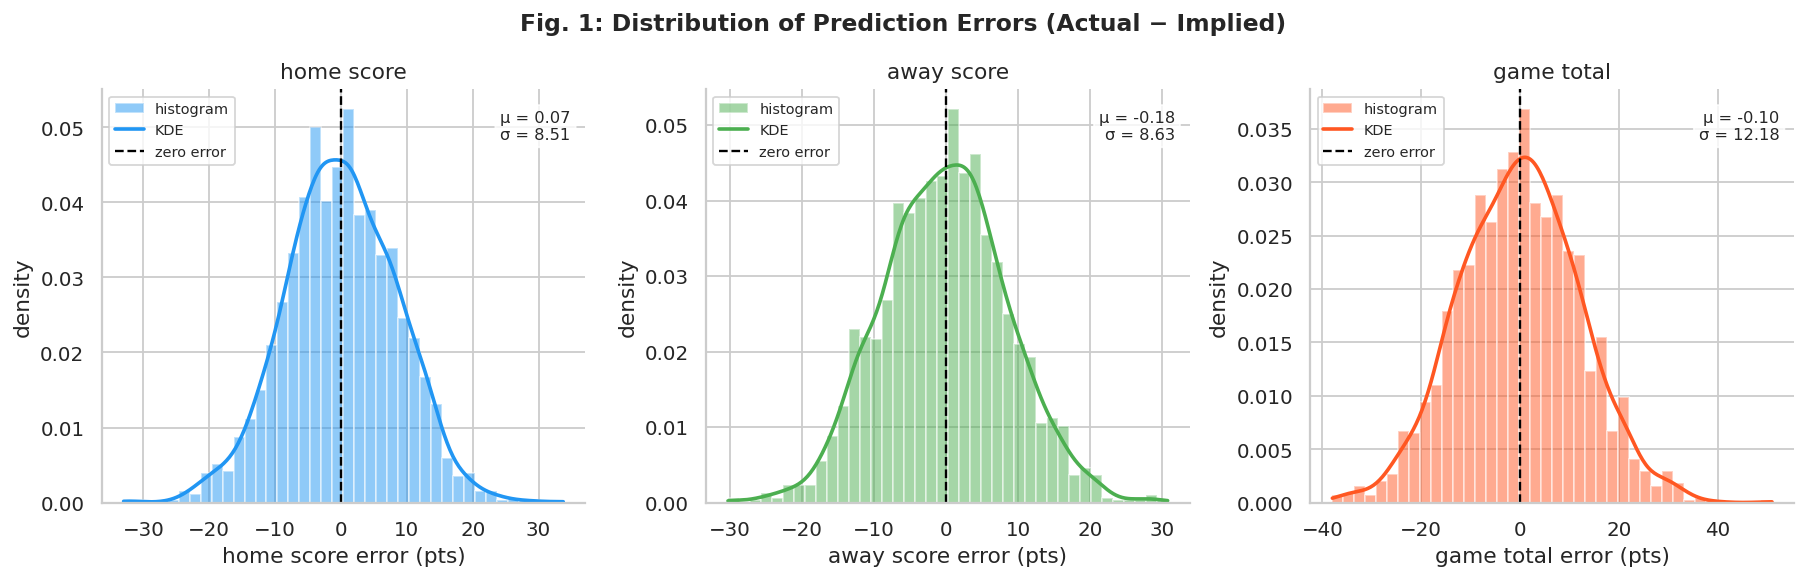

Fig. 1: histograms + KDE overlays of prediction errors for home score, away score, and game total. dashed line marks zero. distributions are centered near zero, consistent with unbiased lines.


In [15]:
fig1, axes = plt.subplots(1, 3, figsize=(14, 4.5))
fig1.suptitle(
    "Fig. 1: Distribution of Prediction Errors (Actual − Implied)",
    fontsize=13, fontweight="bold"
)

def draw_error_panel(ax, data, label, color):
    """histogram + KDE for one error column with a zero-reference line."""

    # density=True normalizes the histogram so area = 1, matching the KDE scale
    ax.hist(data, bins=40, color=color, alpha=0.50, density=True, label="histogram")

    # smooth KDE overlay using scipy's gaussian_kde
    kde_x = np.linspace(data.min(), data.max(), 300)
    kde   = stats.gaussian_kde(data)
    ax.plot(kde_x, kde(kde_x), color=color, lw=2, label="KDE")

    # dashed vertical line at zero = perfect prediction
    ax.axvline(0, color="black", linestyle="--", lw=1.3, label="zero error")

    ax.text(
        0.97, 0.95,
        f"μ = {data.mean():.2f}\nσ = {data.std():.2f}",
        transform=ax.transAxes, ha="right", va="top", fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8)
    )

    ax.set_xlabel(f"{label} error (pts)")
    ax.set_ylabel("density")
    ax.set_title(label)
    ax.legend(fontsize=8)

draw_error_panel(axes[0], df["error_home"],  "home score",  "#2196F3")
draw_error_panel(axes[1], df["error_away"],  "away score",  "#4CAF50")
draw_error_panel(axes[2], df["error_total"], "game total",  "#FF5722")

plt.tight_layout()
plt.savefig("fig1_errors.png", bbox_inches="tight")
plt.show()
print("Fig. 1: histograms + KDE overlays of prediction errors for home score, away score, "
      "and game total. dashed line marks zero. distributions are centered near zero, "
      "consistent with unbiased lines.")

### Fig. 2 — Band Strategy Performance

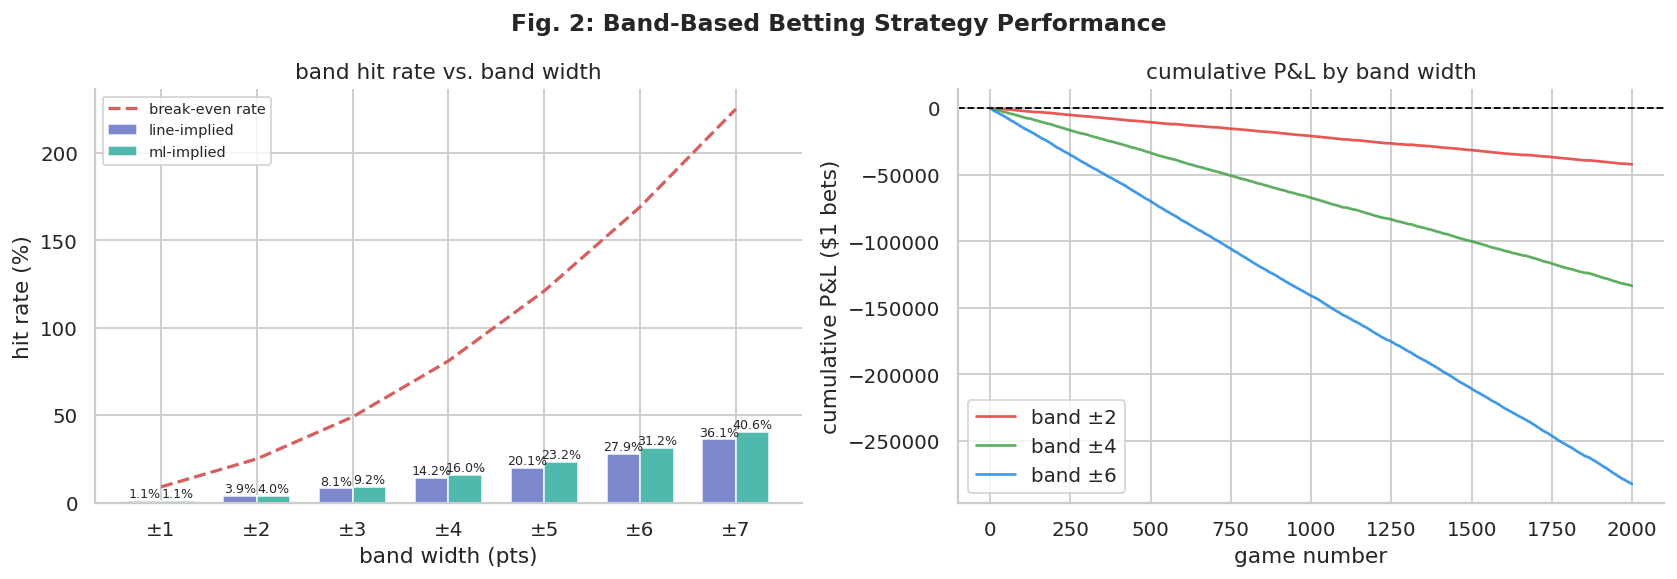

Fig. 2: left — hit rate (bars) vs. break-even at 100x payout (red dashed). right — cumulative P&L for bands ±2, ±4, ±6. negative P&L is expected under the null.


In [16]:
hit_rates_line = []
hit_rates_ml   = []
breakevens     = []

for bw in BAND_WIDTHS:
    pnl_line = compute_band_ev(df, band_width=bw, payout_multiplier=PAYOUT)
    pnl_ml   = compute_band_ev(df, band_width=bw, payout_multiplier=PAYOUT, use_ml_implied=True)
    hit_rates_line.append(pnl_line.attrs["win_mask"].mean() * 100)
    hit_rates_ml.append(pnl_ml.attrs["win_mask"].mean() * 100)
    breakevens.append(pnl_line.attrs["n_bets"] / PAYOUT * 100)

fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
fig2.suptitle("Fig. 2: Band-Based Betting Strategy Performance", fontsize=13, fontweight="bold")

# --- left panel: hit rate vs band width ---
x     = np.arange(len(BAND_WIDTHS))
width = 0.35

bars_line = ax1.bar(x - width/2, hit_rates_line, width, color="#5C6BC0", alpha=0.8, label="line-implied")
bars_ml   = ax1.bar(x + width/2, hit_rates_ml,   width, color="#26A69A", alpha=0.8, label="ml-implied")
ax1.plot(x, breakevens, "r--", lw=1.8, label="break-even rate")
ax1.set_xticks(x)
ax1.set_xticklabels([f"±{bw}" for bw in BAND_WIDTHS])
ax1.set_xlabel("band width (pts)")
ax1.set_ylabel("hit rate (%)")
ax1.set_title("band hit rate vs. band width")
ax1.legend(fontsize=8)

# label bars with their hit rate values
for bar in list(bars_line) + list(bars_ml):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.15,
        f"{bar.get_height():.1f}%", ha="center", va="bottom", fontsize=7
    )

# --- right panel: cumulative P&L ---
palette = ["#E53935", "#43A047", "#1E88E5"]
for bw, color in zip([2, 4, 6], palette):
    pnl = compute_band_ev(df, band_width=bw, payout_multiplier=PAYOUT)
    ax2.plot(pnl.cumsum().values, label=f"band ±{bw}", color=color, lw=1.5, alpha=0.85)

ax2.axhline(0, color="black", linestyle="--", lw=1)
ax2.set_xlabel("game number")
ax2.set_ylabel("cumulative P&L ($1 bets)")
ax2.set_title("cumulative P&L by band width")
ax2.legend()

plt.tight_layout()
plt.savefig("fig2_band.png", bbox_inches="tight")
plt.show()
print("Fig. 2: left — hit rate (bars) vs. break-even at 100x payout (red dashed). "
      "right — cumulative P&L for bands ±2, ±4, ±6. negative P&L is expected under the null.")

### Fig. 3 — Implied vs. Actual Score Comparison

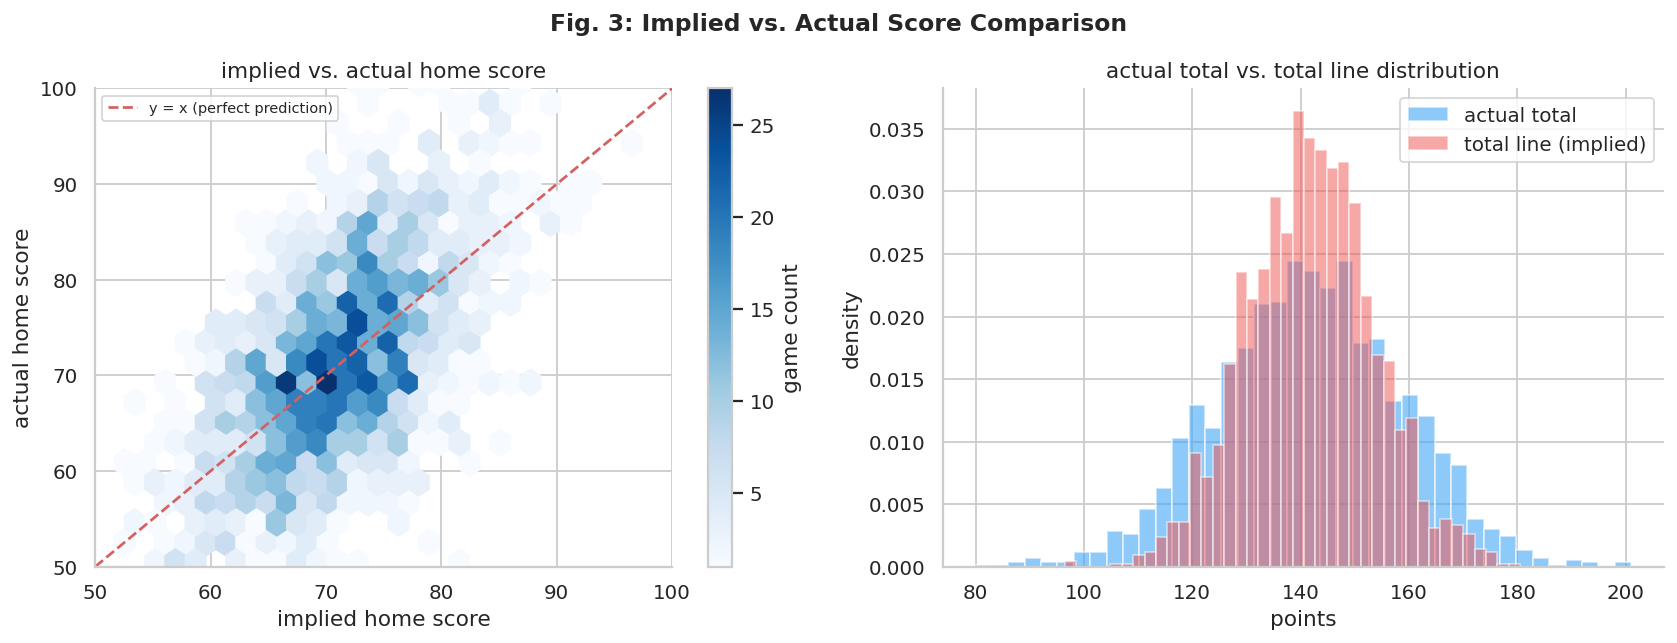

Fig. 3: left — hexbin of implied vs. actual home score; y=x line is perfect prediction. right — actual total (blue) vs. total line (red); near-identical shapes suggest an efficient market.


In [17]:
fig3, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig3.suptitle("Fig. 3: Implied vs. Actual Score Comparison", fontsize=13, fontweight="bold")

# hexbin density plot — groups nearby points into hexagonal bins shaded by count.
# this avoids over-plotting at 2,000 data points and makes the diagonal clear.
hb = ax1.hexbin(df["implied_home"], df["actual_home"], gridsize=30, cmap="Blues", mincnt=1)
fig3.colorbar(hb, ax=ax1, label="game count")

lim = (50, 100)
ax1.plot(lim, lim, "r--", lw=1.5, label="y = x (perfect prediction)")
ax1.set_xlim(lim); ax1.set_ylim(lim)
ax1.set_xlabel("implied home score"); ax1.set_ylabel("actual home score")
ax1.set_title("implied vs. actual home score")
ax1.legend(fontsize=8)

# overlapping histograms: actual total vs total line
# if the market is efficient, these two distributions should be nearly identical
ax2.hist(df["actual_total"], bins=40, alpha=0.6, density=True,
         color="#42A5F5", label="actual total")
ax2.hist(df["total_line"],   bins=40, alpha=0.5, density=True,
         color="#EF5350",   label="total line (implied)")
ax2.set_xlabel("points"); ax2.set_ylabel("density")
ax2.set_title("actual total vs. total line distribution")
ax2.legend()

plt.tight_layout()
plt.savefig("fig3_scatter.png", bbox_inches="tight")
plt.show()
print("Fig. 3: left — hexbin of implied vs. actual home score; y=x line is perfect prediction. "
      "right — actual total (blue) vs. total line (red); near-identical shapes suggest an efficient market.")

### Fig. 4 — Machine Learning Model Results

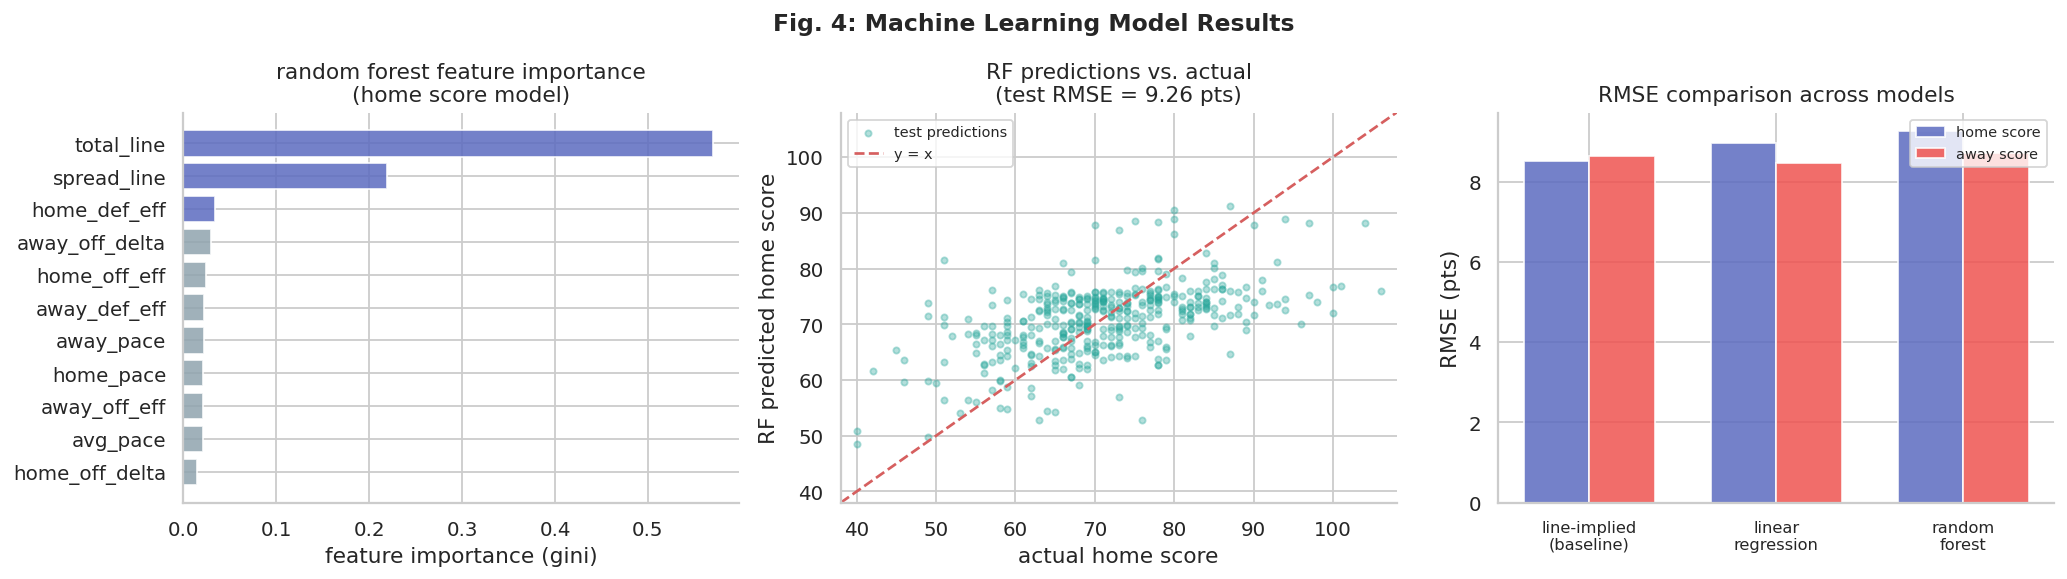

Fig. 4: left — random forest feature importances for the home score model. middle — RF test-set predictions vs. actual home scores. right — RMSE comparison across the three approaches.


In [18]:
fig4, axes = plt.subplots(1, 3, figsize=(16, 4.5))
fig4.suptitle("Fig. 4: Machine Learning Model Results", fontsize=13, fontweight="bold")

# --- left: feature importance bar chart ---
ax = axes[0]
colors = ["#5C6BC0" if i < 3 else "#90A4AE" for i in range(len(importance_df))]
ax.barh(importance_df["feature"], importance_df["importance"], color=colors, alpha=0.85)
ax.invert_yaxis()
ax.set_xlabel("feature importance (gini)")
ax.set_title("random forest feature importance\n(home score model)")
ax.axvline(0, color="black", lw=0.5)

# --- middle: RF predicted vs actual home score (test set) ---
ax = axes[1]
ax.scatter(yh_test, rf_pred_home, alpha=0.35, color="#26A69A", s=12, label="test predictions")
lim = (min(yh_test.min(), rf_pred_home.min()) - 2,
       max(yh_test.max(), rf_pred_home.max()) + 2)
ax.plot(lim, lim, "r--", lw=1.5, label="y = x")
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("actual home score"); ax.set_ylabel("RF predicted home score")
ax.set_title(f"RF predictions vs. actual\n(test RMSE = {rf_rmse_home:.2f} pts)")
ax.legend(fontsize=8)

# --- right: RMSE comparison bar chart ---
ax = axes[2]
models  = ["line-implied\n(baseline)", "linear\nregression", "random\nforest"]
rmse_h  = [line_rmse_home, lr_rmse_home, rf_rmse_home]
rmse_a  = [line_rmse_away, lr_rmse_away, rf_rmse_away]
x_pos   = np.arange(len(models))
width   = 0.35

ax.bar(x_pos - width/2, rmse_h, width, label="home score", color="#5C6BC0", alpha=0.85)
ax.bar(x_pos + width/2, rmse_a, width, label="away score", color="#EF5350", alpha=0.85)
ax.set_xticks(x_pos)
ax.set_xticklabels(models, fontsize=9)
ax.set_ylabel("RMSE (pts)")
ax.set_title("RMSE comparison across models")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("fig4_ml.png", bbox_inches="tight")
plt.show()
print("Fig. 4: left — random forest feature importances for the home score model. "
      "middle — RF test-set predictions vs. actual home scores. "
      "right — RMSE comparison across the three approaches.")

## Section 7 — Summary Output

In [19]:
print("=" * 65)
print("  CS 216 FINAL PROJECT — SUMMARY")
print("=" * 65)

print(f"\n  dataset : {len(df):,} games  |  features: {len(FEATURES)}")

print("\n  ── line-implied prediction accuracy ─────────────────────────")
print(f"  MAE home  : {df['abs_error_home'].mean():.2f} pts")
print(f"  MAE away  : {df['abs_error_away'].mean():.2f} pts")
print(f"  MAE total : {df['abs_error_total'].mean():.2f} pts")
print(f"  std total : {df['error_total'].std():.2f} pts")

print("\n  ── ml model RMSE (test set) ──────────────────────────────────")
print(f"  baseline (line-implied) — home: {line_rmse_home:.3f}  away: {line_rmse_away:.3f}")
print(f"  linear regression       — home: {lr_rmse_home:.3f}  away: {lr_rmse_away:.3f}")
print(f"  random forest           — home: {rf_rmse_home:.3f}  away: {rf_rmse_away:.3f}")

print("\n  ── statistical inference ────────────────────────────────────")
for name, res in inference_results.items():
    print(f"  [{name}] p={res['p_value']} → {res['conclusion']}")

print("\n  ── band strategy (100x payout, line-implied) ────────────────")
print(f"  {'band':>6}  {'hit rate':>9}  {'break-even':>11}  {'mean P&L':>9}  {'95% CI':>22}")
for bw in [2, 4, 6]:
    pnl = compute_band_ev(df, band_width=bw, payout_multiplier=100.0)
    r   = bootstrap_results.get(bw, {})
    ci  = f"[${r.get('ci_lower', 0):.2f}, ${r.get('ci_upper', 0):.2f}]" if r else "n/a"
    print(f"  ±{bw:>3}    {pnl.attrs['win_mask'].mean():>8.2%}   "
          f"{pnl.attrs['n_bets']/100.0:>9.2%}   ${pnl.mean():>7.2f}   {ci}")

print("\n  figures saved: fig1_errors.png  fig2_band.png  fig3_scatter.png  fig4_ml.png")
print("=" * 65)

  CS 216 FINAL PROJECT — SUMMARY

  dataset : 2,000 games  |  features: 11

  ── line-implied prediction accuracy ─────────────────────────
  MAE home  : 6.78 pts
  MAE away  : 6.89 pts
  MAE total : 9.71 pts
  std total : 12.18 pts

  ── ml model RMSE (test set) ──────────────────────────────────
  baseline (line-implied) — home: 8.513  away: 8.629
  linear regression       — home: 8.974  away: 8.460
  random forest           — home: 9.259  away: 8.708

  ── statistical inference ────────────────────────────────────
  [total_error_bias] p=0.704 → fail to reject H0 — no bias
  [home_error_bias] p=0.6976 → fail to reject H0 — no bias
  [normality_total_error] p=0.7968 → consistent with normality

  ── band strategy (100x payout, line-implied) ────────────────
    band   hit rate   break-even   mean P&L                  95% CI
  ±  2       3.90%      25.00%   $ -21.10   [$-21.90, $-20.25]
  ±  4      14.25%      81.00%   $ -66.75   [$-68.15, $-65.20]
  ±  6      27.90%     169.00%   $-14